In [1]:
import numpy as np
import matplotlib.pyplot as pl
import matplotlib as mpl
pl.style.use("../paper.mplstyle")

pi = np.pi

## Constant f

In [2]:
f0 = 0.5*2*pi
t_space = np.linspace(0, 10, 2**10)
signal = np.sin(f0*t_space)
mark_idx = np.arange(0, len(signal), 30)
colorbar = mpl.colormaps['hsv']

## Changing f

In [23]:
t_space = np.linspace(0, 8, 2**10)
f = 0.5*2*pi + 0.004*t_space**3
signal = np.sin(f*t_space)
mark_idx = np.arange(0, len(signal), 30)
tau = (1+0.003*t_space**3/(0.5*2*pi))*t_space
color_arr = np.multiply(0.7,[colorbar(int(np.mod(i/2, 1)*255)) for i in tau])

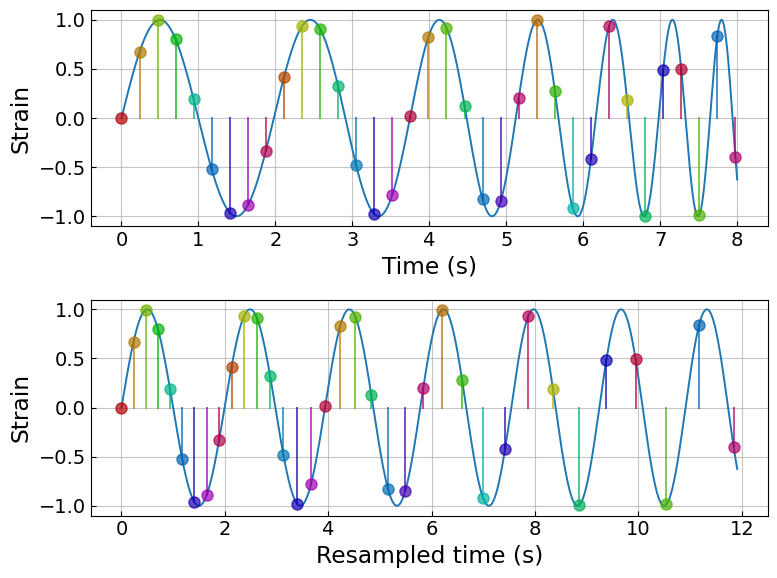

In [24]:
fig, axs = pl.subplots(2, figsize = (8, 6))

axs[0].plot(t_space, signal, c='tab:blue')
axs[0].grid(True)
for i in mark_idx:
    axs[0].plot([t_space[i]], [signal[i]], marker = 'o', markersize=8, c=color_arr[i])
    axs[0].plot([t_space[i], t_space[i]], [0, signal[i]], c=color_arr[i])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Strain")

axs[1].plot(tau, signal, c='tab:blue')
for i in mark_idx:
    axs[1].plot([tau[i]], [signal[i]], marker = 'o', markersize=8, c=color_arr[i])
    axs[1].plot([tau[i], tau[i]], [0, signal[i]], c=color_arr[i])
axs[1].set_xlabel("Resampled time (s)")
axs[1].set_ylabel("Strain")
axs[1].grid(True)

fig.tight_layout()
# pl.savefig("figs/resampling_graphic.png")

## Interpolation onto a uniform resampled-time grid

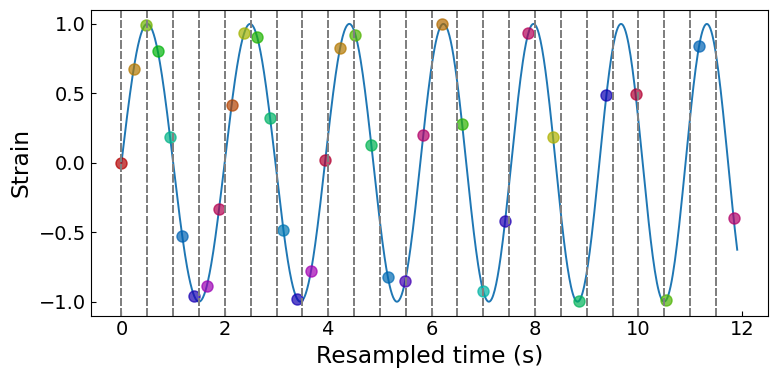

In [26]:
fig, ax = pl.subplots(1, figsize = (8, 4))


ax.plot(tau, signal, c='tab:blue')
for i in mark_idx:
    ax.plot([tau[i]], [signal[i]], marker = 'o', markersize=8, c=color_arr[i])
    [ax.axvline([x], c='grey', ls='--') for x in np.arange(min(tau), max(tau)+1e-2, 0.5)]
    # ax.plot([tau[i], tau[i]], [0, signal[i]], c=color_arr[i])
ax.set_xlabel("Resampled time (s)")
ax.set_ylabel("Strain")
# ax.grid(True)

fig.tight_layout()
# pl.savefig("figs/resampling_graphic.png")